# Convolução 2D em Imagens

Este notebook demonstra, de forma **didática**, como funciona a **convolução 2D** aplicada a imagens:
- o que é um **kernel/máscara** e como ele afeta a imagem (suavização, realce, bordas);
- como aplicar a convolução usando uma implementação **manual** (laços) disponível em `utils.py`;
- cuidados importantes: **padding**, kernels com valores **negativos**, **normalização** e **clipping**.

> **Dica:** se você quiser usar uma imagem própria, basta colocar o arquivo na mesma pasta do notebook e ajustar `IMG_PATH`.

### 1) Importações

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

import utils as ut

### 2) Leitura da imagem

In [2]:
IMG_PATH = Path("tchoro.jpg")

image = cv.imread(str(IMG_PATH), cv.IMREAD_COLOR)

if image is None:
    raise FileNotFoundError(f"Não consegui ler o arquivo: {IMG_PATH.resolve()}")

print("Imagem carregada com sucesso!")

Imagem carregada com sucesso!


### 3) Análise exploratória

In [3]:
ut.eda_image(image)

Largura em pixels: 960
Altura em pixels: 960
Quantidade de pixels: 921600
Quantidade de elementos presentes na matriz: 2764800
Quantidade de canais: 3


### 4) Converter para tons de cinza

A convolução 2D costuma ser apresentada primeiro em imagens **de 1 canal** (tons de cinza),
pois o cálculo fica mais simples:

- imagem cinza: matriz 2D `(H, W)`
- kernel: matriz 2D `(kH, kW)` com dimensões ímpares (3x3, 5x5, ...)

Depois você pode estender para RGB aplicando a convolução em cada canal (R, G, B) separadamente.


In [4]:
grayChannel = ut.generate_gray_channel(image)

cv.imshow("Imagem recriada", grayChannel)
cv.waitKey(0)

-1

### 5) O que é convolução? (intuição + fórmula)

Um filtro por convolução percorre a imagem e, para cada posição, calcula uma **combinação ponderada**
de uma vizinhança local.

Seja:

- imagem \(I\)
- kernel \(K\) (também chamado máscara)

Para cada pixel \((i, j)\):

\[
(I * K)[i, j] = \sum_{u}\sum_{v} I[i+u, j+v] \cdot K[u, v]
\]

### Pontos importantes

- **Dimensões ímpares** do kernel (3x3, 5x5, ...) garantem um “centro”.
- **Padding**: para filtrar bordas, costuma-se preencher a imagem com zeros (ou replicar borda).
- **Kernels com negativos** (ex.: detecção de bordas) geram valores negativos → exige cuidado na visualização:
  - se você simplesmente fizer `clip(0,255)`, parte da informação é perdida.


In [5]:
mask_size = int(input("Digite o tamanho da máscara (ímpar, ex.: 3, 5, 7): "))

In [6]:
filtered = ut.automatic_convolution(grayChannel, mask_size=mask_size, random_seed=True)

cv.imshow(f"Imagem filtrada (máscara {mask_size}x{mask_size})", filtered)
cv.waitKey(0)
cv.destroyAllWindows()

Kernel usado na convolução:
[[0 1 0]
 [0 0 1]
 [0 0 0]]


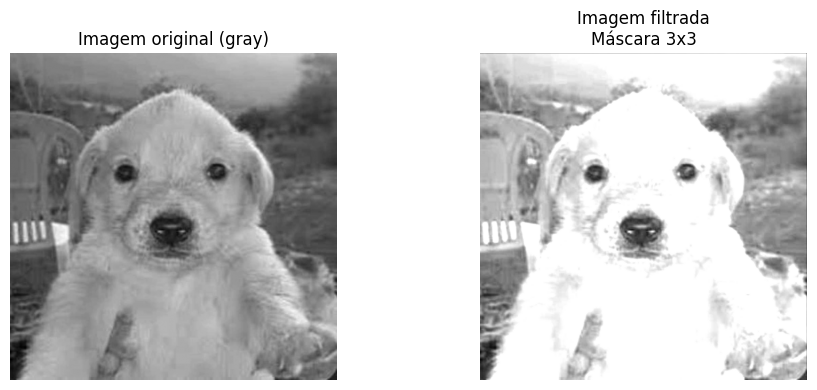

In [7]:
ut.show_images_side_by_side(grayChannel, filtered, mask_size)

### 6) Detector de arestas Laplaciano (kernel visto em aula)

No seu `utils.py` existe uma função `apply_laplacian_filter` que:
- aplica o kernel Laplaciano 4-vizinhos;
- usa `abs()` para não “sumir” com valores negativos;
- normaliza o resultado para [0,255].

Isso costuma produzir uma visualização de bordas bem melhor.

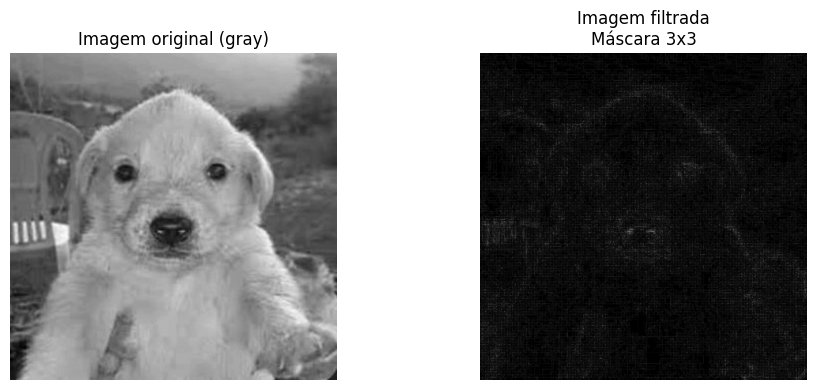

In [5]:
edges = ut.apply_laplacian_filter(grayChannel)
ut.show_images_side_by_side(grayChannel, edges, mask_size=3)